# TinyML - Neural Additive Models

**Author:** Thommas Kevin Sales Flores  

**Institution:** Federal University of Rio Grande do Norte

**Email:** thommas.flores.101@ufrn.edu.br

This notebook implements a complete framework for Neural Additive Models (NAM) in Python, using TensorFlow/Keras. It includes:
- A `NAM` class for regression, binary classification, and **multiclass classification** (softmax).
- Saving/loading model parameters to/from JSON.
- Generating embeddable C code for microcontrollers (Arduino, ESP32, etc.).
- Examples with visualizations for all three tasks.

## 1. Importing Libraries

In [ ]:
import sys
sys.path.append("31_NAM")
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
import json
import matplotlib.pyplot as plt
from model.nam import *

## 2. Utility Functions for Visualization

In [28]:
def get_feature_contribution(nam, feature_name, x_values):
    """
    Returns the output of a single feature network for given raw input values.
    For multiclass, this returns a vector of logits (one per class).
    """
    idx = nam.feature_names.index(feature_name)
    x_scaled = (x_values - nam.scaler.mean_[idx]) / nam.scaler.scale_[idx]

    inp_tensor = nam.model.get_layer(feature_name).output   # FIXED: use .output
    out_tensor = nam.model.get_layer(f'{feature_name}_out').output
    feature_model = tf.keras.models.Model(inputs=inp_tensor, outputs=out_tensor)
    return feature_model.predict(x_scaled.reshape(-1, 1))

def get_feature_logits(nam, feature_name, x_values):
    """Alias for get_feature_contribution (for multiclass)."""
    return get_feature_contribution(nam, feature_name, x_values)

## 3. Regression Example
Synthetic data: y = sin(2π x1) + 0.3 * x2² + noise

In [29]:
np.random.seed(42)
n = 2000
x1 = np.random.uniform(0, 1, n)
x2 = np.random.uniform(0, 1, n)
y = np.sin(2 * np.pi * x1) + 0.3 * x2**2 + 0.1 * np.random.randn(n)
X = pd.DataFrame({'x1': x1, 'x2': x2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

nam_reg = NAM(feature_names=['x1', 'x2'], hidden_units=[32, 16], activation='relu')
history = nam_reg.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=0)

y_pred = nam_reg.predict(X_test).flatten()
print(f"Regression Test MSE: {np.mean((y_test - y_pred)**2):.4f}")

nam_reg.save_parameters('.\\arduino_code\\regression\\nam_regression.json')
nam_reg.export_to_c('.\\arduino_code\\regression\\nam_regression.h')
print("Regression model saved and exported.")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Regression Test MSE: 0.0107
Regression model saved and exported.


### 3.1 Regression Error Visualizations

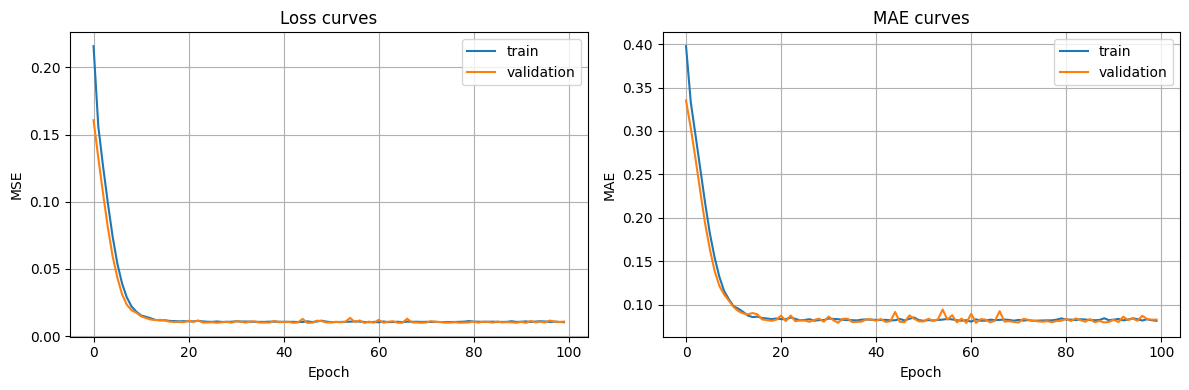

In [30]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Loss curves')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE curves')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

### 3.2 Regression Prediction Visualizations

In [31]:
print("X = ", X_train.to_numpy()[0])
print("True = ", y_train[0])
print("Predicted = ", nam_reg.predict(X_train).flatten()[0])

X =  [0.22793516 0.98411032]
True =  1.0657087912546495
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Predicted =  1.2335348


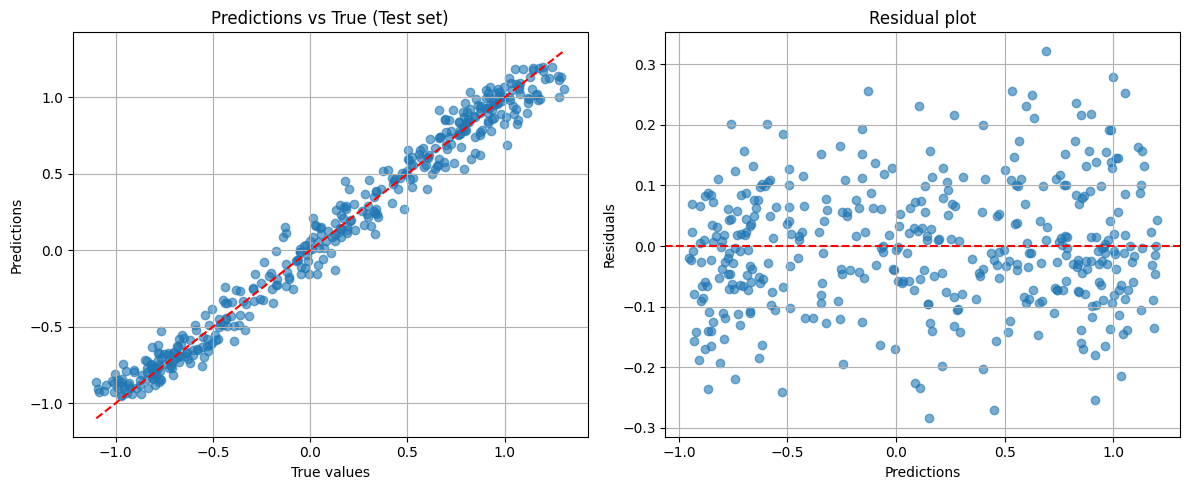

In [32]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True values')
plt.ylabel('Predictions')
plt.grid()
plt.title('Predictions vs True (Test set)')

plt.subplot(1,2,2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.title('Residual plot')
plt.tight_layout()
plt.grid()
plt.show()

### 3.3 Regression Learned Shape Function Visualizations

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


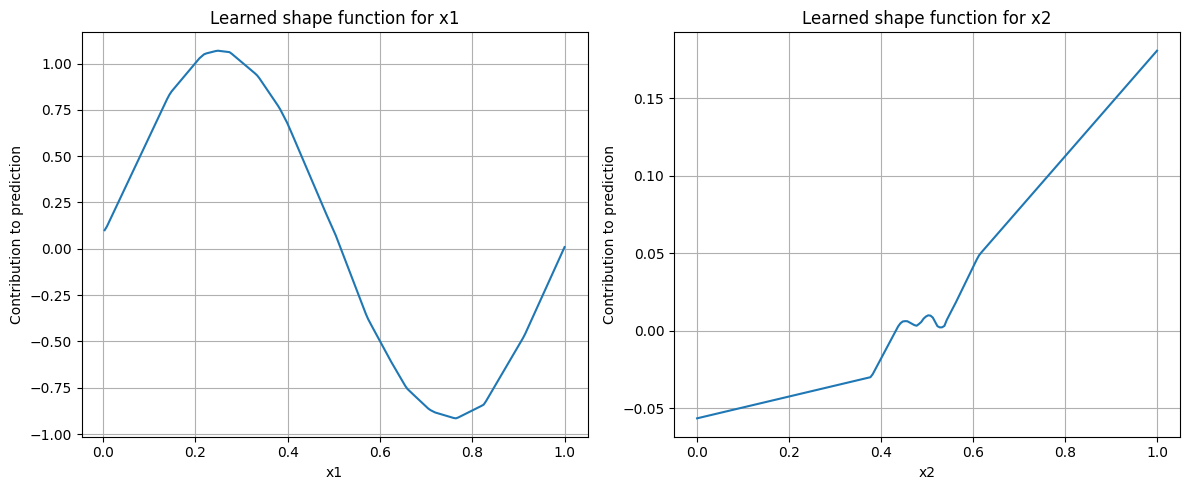

In [33]:
x1_grid = np.linspace(X['x1'].min(), X['x1'].max(), 200)
x2_grid = np.linspace(X['x2'].min(), X['x2'].max(), 200)

contrib_x1 = get_feature_contribution(nam_reg, 'x1', x1_grid).flatten()
contrib_x2 = get_feature_contribution(nam_reg, 'x2', x2_grid).flatten()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x1_grid, contrib_x1)
plt.xlabel('x1')
plt.ylabel('Contribution to prediction')
plt.title('Learned shape function for x1')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x2_grid, contrib_x2)
plt.xlabel('x2')
plt.ylabel('Contribution to prediction')
plt.title('Learned shape function for x2')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. Binary Classification Example

In [34]:
np.random.seed(42)
x1 = np.random.uniform(0, 1, n)
x2 = np.random.uniform(0, 1, n)
z = np.sin(2 * np.pi * x1) + x2
prob = 1 / (1 + np.exp(-5*(z - 0.5)))
y = (np.random.random(n) < prob).astype(int)
X = pd.DataFrame({'x1': x1, 'x2': x2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

nam_clf = NAM(feature_names=['x1', 'x2'], hidden_units=[16, 8],
              activation='relu', output_activation='sigmoid')
history = nam_clf.fit(X_train, y_train, epochs=100, batch_size=32,
                      validation_split=0.2, verbose=0,
                      loss='binary_crossentropy', metrics=['accuracy'])

y_pred_prob = nam_clf.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
acc = np.mean(y_pred == y_test)
print(f"Binary classification test accuracy: {acc:.4f}")

nam_clf.save_parameters('.\\arduino_code\\classification_binary\\nam_binary.json')
nam_clf.export_to_c('.\\arduino_code\\classification_binary\\nam_binary.h')
print("Binary model saved and exported.")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Binary classification test accuracy: 0.9050
Binary model saved and exported.


In [35]:
print("X = ", X_train.to_numpy()[0])
print("True = ", y_train[0])
print("Predicted = ", nam_clf.predict(X_train).flatten()[0])

X =  [0.07118865 0.67296662]
True =  1
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Predicted =  0.9402194


### 4.1 Binary Classification Error Visualizations

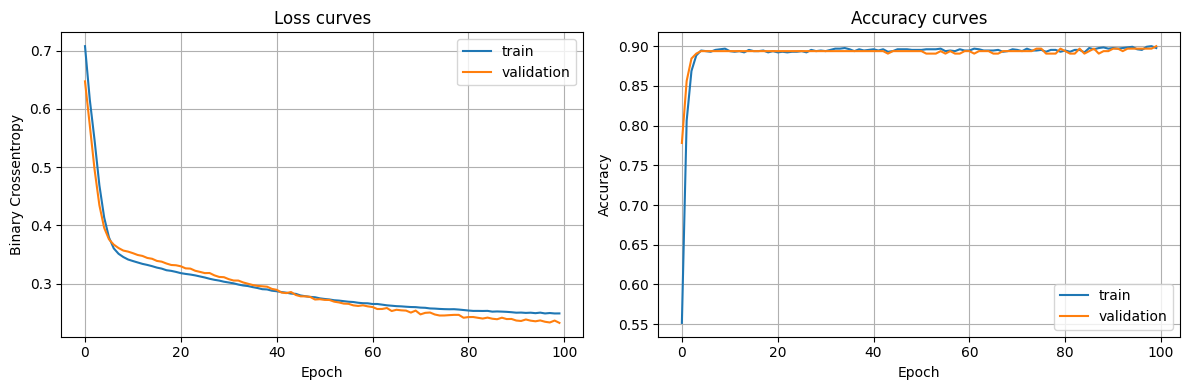

In [36]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.title('Loss curves')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy curves')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

### 4.2 Binary Classification Visualization

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


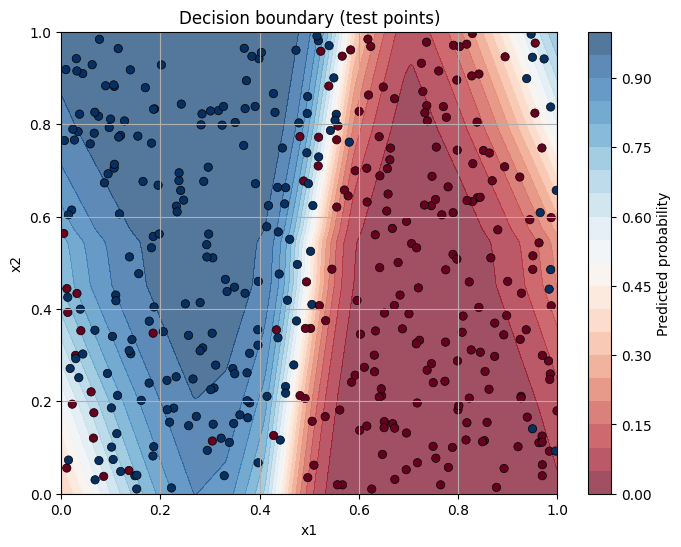

In [37]:
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=['x1', 'x2'])
probs = nam_clf.predict(grid_df).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.7)
plt.colorbar(label='Predicted probability')
plt.scatter(X_test['x1'], X_test['x2'], c=y_test, edgecolors='k', cmap='RdBu', linewidth=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision boundary (test points)')
plt.grid()
plt.show()

### 4.3 Binary Classification Learned Shape Function Visualizations

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


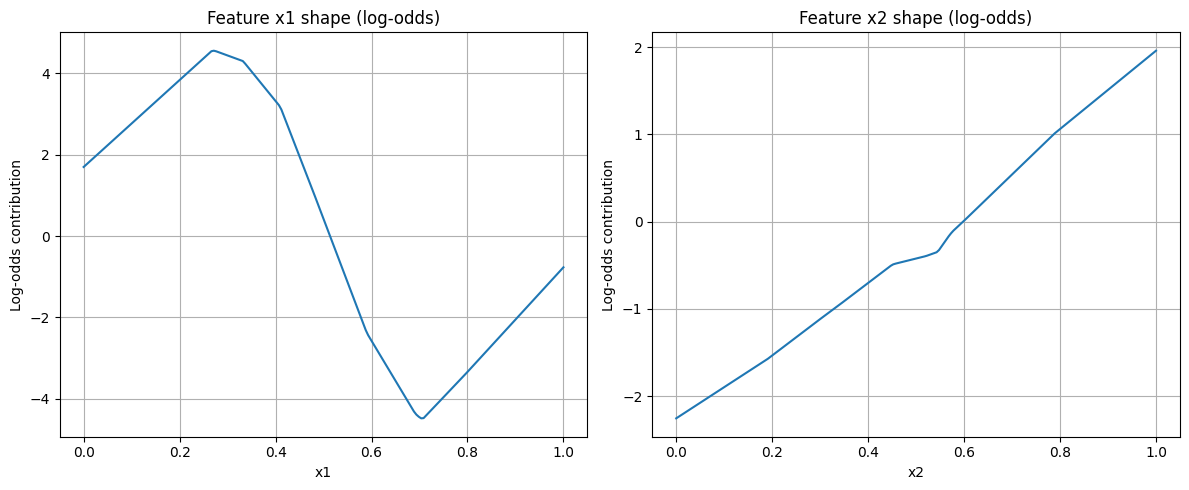

In [38]:
x1_grid = np.linspace(0, 1, 200)
x2_grid = np.linspace(0, 1, 200)

contrib_x1 = get_feature_contribution(nam_clf, 'x1', x1_grid).flatten()
contrib_x2 = get_feature_contribution(nam_clf, 'x2', x2_grid).flatten()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(x1_grid, contrib_x1)
plt.xlabel('x1')
plt.ylabel('Log-odds contribution')
plt.title('Feature x1 shape (log-odds)')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(x2_grid, contrib_x2)
plt.xlabel('x2')
plt.ylabel('Log-odds contribution')
plt.title('Feature x2 shape (log-odds)')
plt.grid(True)
plt.tight_layout()
plt.show()

---
# 5. Example 3: Multiclass Classification 
Synthetic data with 3 classes based on a circle and corners.

In [39]:
np.random.seed(42)
n_multi = 3000
x1 = np.random.uniform(-1.5, 1.5, n_multi)
x2 = np.random.uniform(-1.5, 1.5, n_multi)

r = np.sqrt(x1**2 + x2**2)
y = np.zeros(n_multi, dtype=int)
y[r < 0.8] = 0
y[(r >= 0.8) & (np.abs(x1) < 1.2) & (np.abs(x2) < 1.2)] = 1
y[(r >= 0.8) & ((np.abs(x1) >= 1.2) | (np.abs(x2) >= 1.2))] = 2
# Add noise: randomly flip 5% of labels
flip = np.random.random(n_multi) < 0.05
y[flip] = np.random.randint(0, 3, size=np.sum(flip))

X = pd.DataFrame({'x1': x1, 'x2': x2})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=3)

nam_multi = NAM(feature_names=['x1', 'x2'], hidden_units=[16, 8],
                activation='relu', output_activation='softmax', num_classes=3)
history = nam_multi.fit(X_train, y_train_onehot, epochs=100, batch_size=32,
                        validation_split=0.2, verbose=0,
                        loss='categorical_crossentropy', metrics=['accuracy'])

y_pred_probs = nam_multi.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
acc = np.mean(y_pred == y_test)
print(f"Multiclass test accuracy: {acc:.4f}")

nam_multi.save_parameters('.\\arduino_code\\classification_multiclass\\nam_multiclass.json')
nam_multi.export_to_c('.\\arduino_code\\classification_multiclass\\nam_multiclass.h')
print("Multiclass model saved and exported.")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Multiclass test accuracy: 0.9300
Multiclass model saved and exported.


### 5.1 Multiclass Classification Error Visualizations

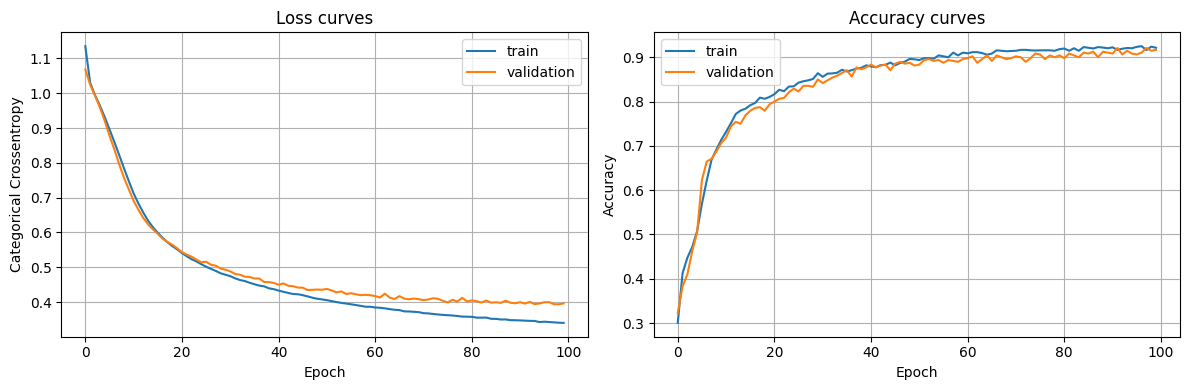

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy')
plt.title('Loss curves')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy curves')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

### 5.2 Multiclass Classification Visualizations

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step


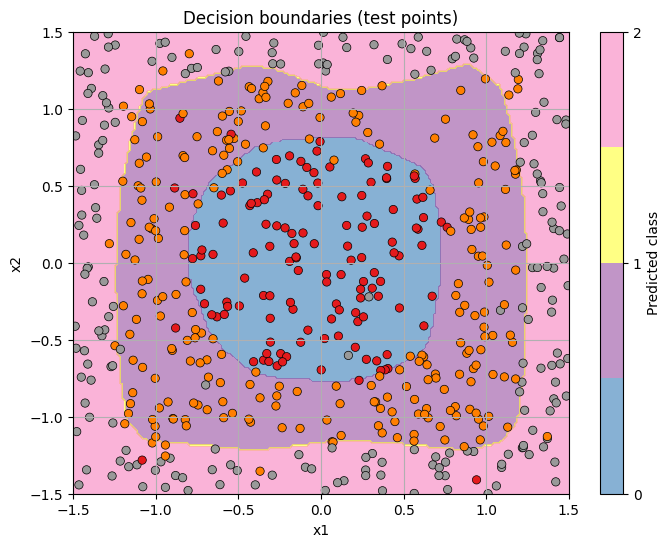

In [ ]:
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200),
                     np.linspace(-1.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_df = pd.DataFrame(grid, columns=['x1', 'x2'])
probs = nam_multi.predict(grid_df)  # shape (40000, 3)
pred_classes = np.argmax(probs, axis=1).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, pred_classes, levels=3, alpha=0.6, cmap='Set1')
plt.colorbar(ticks=[0,1,2], label='Predicted class')
plt.scatter(X_test['x1'], X_test['x2'], c=y_test, edgecolors='k', cmap='Set1', linewidth=0.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision boundaries (test points)')
plt.grid()
plt.show()

### 5.3 Multiclass Classification Learned Shape Function Visualizations

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


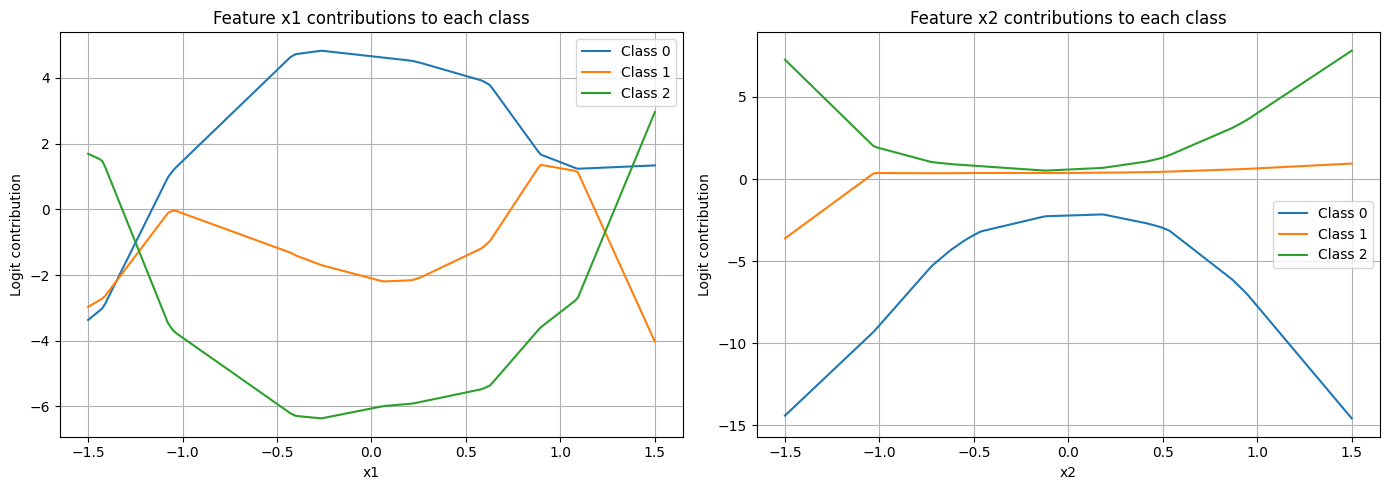

In [ ]:
x1_grid = np.linspace(-1.5, 1.5, 200)
x2_grid = np.linspace(-1.5, 1.5, 200)

logits_x1 = get_feature_logits(nam_multi, 'x1', x1_grid)   # shape (200, 3)
logits_x2 = get_feature_logits(nam_multi, 'x2', x2_grid)

plt.figure(figsize=(14,5))
for i, cls in enumerate(['Class 0', 'Class 1', 'Class 2']):
    plt.subplot(1,2,1)
    plt.plot(x1_grid, logits_x1[:, i], label=cls)
    plt.xlabel('x1')
    plt.ylabel('Logit contribution')
    plt.title('Feature x1 contributions to each class')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(x2_grid, logits_x2[:, i], label=cls)
    plt.xlabel('x2')
    plt.ylabel('Logit contribution')
    plt.title('Feature x2 contributions to each class')
    plt.legend()
    plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Load Saved Model and Verify
Load the multiclass model from JSON and compare predictions.

In [ ]:
nam_loaded = NAM(feature_names=['x1', 'x2'], hidden_units=[16, 8],
                 activation='relu', output_activation='softmax', num_classes=3)
nam_loaded.load_parameters('.\\arduino_code\\classification_multiclass\\nam_multiclass.json')

y_pred_loaded = nam_loaded.predict(X_test)
print("Max difference between original and loaded predictions:",
      np.max(np.abs(y_pred_probs - y_pred_loaded)))

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Max difference between original and loaded predictions: 0.0
